In [19]:
import matplotlib.pyplot as plt
from Environment import *

num_agents = 10                   
num_rounds = 200
num_episodes = 10
b = [2, 5, 10]           # Benefit
c = 1                    # Cost of cooperation
chi = 0.01  # Reputation assignment error

In [20]:
def run(payoffs, norm, seed_number):


    agents = [Qlearner(seeded=True) for _ in range(seed_number)] + [Qlearner(seeded=False) for _ in range(10-seed_number)]
    env = MatrixGame(payoffs, agents, norm)
    print("Norm:", env.norm)

    for episode in range(num_episodes):
        if episode%100==0:
            print(f"Number of episodes: {episode}")
        obs = env.reset()
        prev_obs = None
        prev_actions = {}
        prev_rewards = {}
        prev_opponents = {}
        for round in range(num_rounds):
            next_obs, rewards, actions = env.step()
            last_opponent = env.last_opponent
            if prev_obs is not None:
                for agent in agents:
                    s = prev_obs[prev_opponents[agent]]
                    a = prev_actions[agent]
                    r = prev_rewards[agent]
                    s_next = obs[last_opponent[agent]]
                    if round == num_rounds - 1:
                        agent.update(s, a, s_next, r, done=True)
                    else:
                        agent.update(s, a, s_next, r, done=False)
            prev_obs = obs
            prev_actions = actions
            prev_rewards = rewards
            prev_opponents = last_opponent
            obs = next_obs


    average_agent_round_payoff = np.zeros(num_episodes//2)
    for agent in agents:
        average_round_payoff = np.array(agent.episode_total_rewards[num_episodes//2:])/num_rounds
        average_agent_round_payoff += average_round_payoff

    b = payoffs[0,1]
    average_agent_round_payoff = (average_agent_round_payoff.sum()/(10*(num_episodes//2)))/(b-c)

    return average_agent_round_payoff

Norm: [1, 0, 0, 1]
Number of episodes: 0
----------------------------------------
element :  0
resultat:  [np.float64(0.138)]
Norm: [1, 0, 0, 1]
Number of episodes: 0
----------------------------------------
element :  1
resultat:  [np.float64(0.138), np.float64(0.2626)]
Norm: [1, 0, 0, 1]
Number of episodes: 0
----------------------------------------
element :  2
resultat:  [np.float64(0.138), np.float64(0.2626), np.float64(0.3319)]
Norm: [1, 0, 0, 1]
Number of episodes: 0
----------------------------------------
element :  3
resultat:  [np.float64(0.138), np.float64(0.2626), np.float64(0.3319), np.float64(0.36329999999999996)]
Norm: [1, 0, 0, 1]
Number of episodes: 0
----------------------------------------
element :  4
resultat:  [np.float64(0.138), np.float64(0.2626), np.float64(0.3319), np.float64(0.36329999999999996), np.float64(0.3098)]
Norm: [1, 0, 0, 1]
Number of episodes: 0
----------------------------------------
element :  5
resultat:  [np.float64(0.138), np.float64(0.2626)

ValueError: x and y must have same first dimension, but have shapes (6,) and (12,)

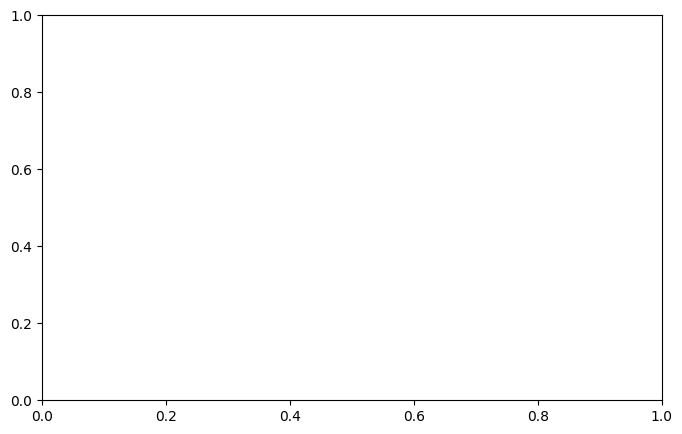

In [21]:
results_effective = []
results_ineffective = []
colors = ["blue", "red"]

effective_norm =[1,0,0,1]
ineffective_norm =[0,0,0,0]

seeded_list = [0,1,2,3,4,5]

payoffs = np.array([[0, b[1]],[-c, b[1]-c]])


for seed in seeded_list:
    results_effective.append(run(payoffs, effective_norm, seed))
    print("----------------------------------------")
    print("element : ",seed)
    print("resultat: ", results_effective)


for seed in seeded_list:
    results_effective.append(run(payoffs, ineffective_norm, seed))

print(len(results_effective))


results_effective = np.array(results_effective)
results_effective *= 100
results_ineffective = np.array(results_ineffective)
results_ineffective *= 100


# Axe X : pourcentage de seeded agents
x = np.array(seeded_list) * 10

plt.figure(figsize=(8, 5))

# Courbe effective (bleu)
print(x)
print(results_effective)
plt.plot(
    x,
    results_effective,
    color="blue",
    marker="o",
    label="Effective norm"
)

# Courbe ineffective (rouge)
plt.plot(
    x,
    results_ineffective,
    color="red",
    marker="o",
    label="Ineffective norm"
)

# Limites des axes
plt.ylim(0, 100)
plt.xlim(0, 50)

# Labels
plt.xlabel("Seeded agents (%)")
plt.ylabel("Result (%)")
plt.title("Cooperation in the long run")

# Légende et grille
plt.legend()
plt.grid(True)

plt.show()
